# Online news popularity

The aim is to predict an article's share count from its content statistics.

We're working with the [Online News Popularity](https://archive.ics.uci.edu/ml/datasets/online+news+popularity) dataset from Mashable. Each row is an article, and we want to predict how many times it was shared. The features are all metadata (word counts, keywords, topic scores, sentiment), not the actual article text.

This EDA will help us understand the data, spot issues, and decide what features to keep before building regression models.

In [2]:
# standard data science imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_rows", 80)
np.random.seed(42)

## Loading the data

In [3]:
# load data, clean column names, and check basic stats
df = pd.read_csv("../datasets/online_news_popularity.csv")
df.columns = df.columns.str.strip()
print("Shape:", df.shape)
display(df.head())
audit = pd.DataFrame({"dtype": df.dtypes.astype(str), "missing": df.isna().sum(), "unique": df.nunique()})
display(audit)
print("Exact duplicates:", df.duplicated().sum())
display(df["shares"].describe())

Shape: (39644, 61)


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


,dtype,missing,unique
url,str,0,39644
timedelta,float64,0,724
n_tokens_title,float64,0,20
n_tokens_content,float64,0,2406
n_unique_tokens,float64,0,27281
n_non_stop_words,float64,0,1451
n_non_stop_unique_tokens,float64,0,22930
num_hrefs,float64,0,133
num_self_hrefs,float64,0,59
num_imgs,float64,0,91


Exact duplicates: 0


count     39644.000000
mean       3395.380184
std       11626.950749
min           1.000000
25%         946.000000
50%        1400.000000
75%        2800.000000
max      843300.000000
Name: shares, dtype: float64

There are 39,644 articles and 61 columns. The file has no missing values or duplicate rows. The URL is an identifier, and `timedelta` measures time from publication to dataset collection, so both are left out.

61 columns is a lot of features for ~40k articles. Most are numeric, and there are no missing values, which is nice. The `url` and `timedelta` columns won't help with prediction, so we'll drop those right away.

In [4]:
# drop identifiers, fix bad ratios, and create the train/test split
print("Repeated article URLs:", df["url"].duplicated().sum())
df = df.drop_duplicates(subset="url").copy()
ratio_cols = ["n_unique_tokens", "n_non_stop_words", "n_non_stop_unique_tokens"]
bad = (df[ratio_cols] < 0) | (df[ratio_cols] > 1.00001)
display(bad.sum().rename("Invalid ratios"))
df[ratio_cols] = df[ratio_cols].mask(bad)
x = df.drop(columns=["url", "timedelta", "shares"])
y = df["shares"]
bins = pd.qcut(y, q=5, labels=False, duplicates="drop")
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=bins
)

Repeated article URLs: 0


n_unique_tokens             1
n_non_stop_words            1
n_non_stop_unique_tokens    1
Name: Invalid ratios, dtype: int64

One row has word ratios above 1. These values are replaced with missing values and later filled using the training median. The 80:20 split uses five share-count bands for stratification.

In [5]:
print("Training rows:", len(x_train), "Test rows:", len(x_test))
display(pd.DataFrame({"train": y_train.describe(), "test": y_test.describe()}))
data = x_train.copy()
data[y.name] = y_train

Training rows: 31715 Test rows: 7929


,train,test
count,31715.000000,7929.000000
mean,3423.133628,3284.369908
std,12004.851334,9973.138376
min,4.000000,1.000000
25%,946.000000,947.000000
50%,1400.000000,1400.000000
75%,2800.000000,2800.000000
max,843300.000000,617900.000000


## Distributions

The following plots use the training set.

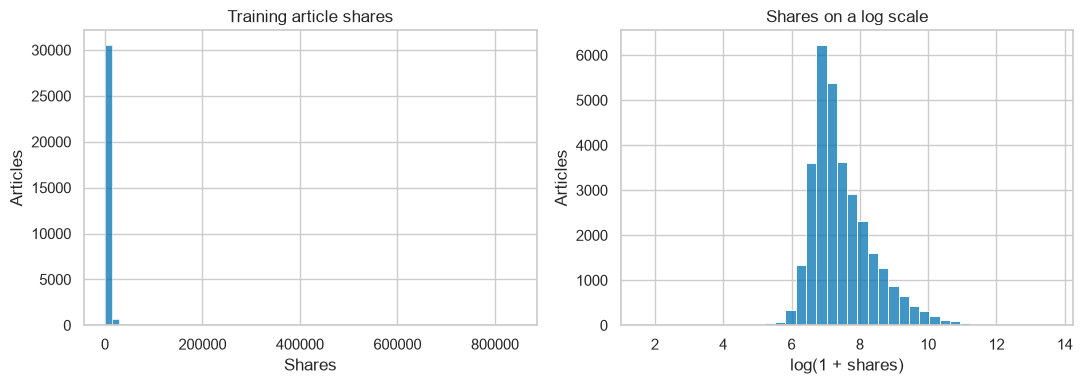

0.50      1400.0
0.90      6200.0
0.99     32000.0
1.00    843300.0
Name: Shares, dtype: float64

In [6]:
# visualize target distribution (raw and log-scaled)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(y_train, bins=60, ax=ax[0])
ax[0].set(title="Training article shares", xlabel="Shares", ylabel="Articles")
sns.histplot(np.log1p(y_train), bins=40, ax=ax[1])
ax[1].set(title="Shares on a log scale", xlabel="log(1 + shares)", ylabel="Articles")
plt.tight_layout()
plt.show()
display(y_train.quantile([0.5, 0.9, 0.99, 1]).rename("Shares"))

Shares are strongly right-skewed. Most articles have modest counts, while a few have very large counts. The log view makes the middle of the distribution easier to see.

This heavy right skew is really important. A handful of articles go viral with tens of thousands of shares, but the typical article gets around 1,400. This means our regression models are going to struggle because a few extreme values will dominate the squared error. The log view shows that the distribution looks much more "normal" after transformation.

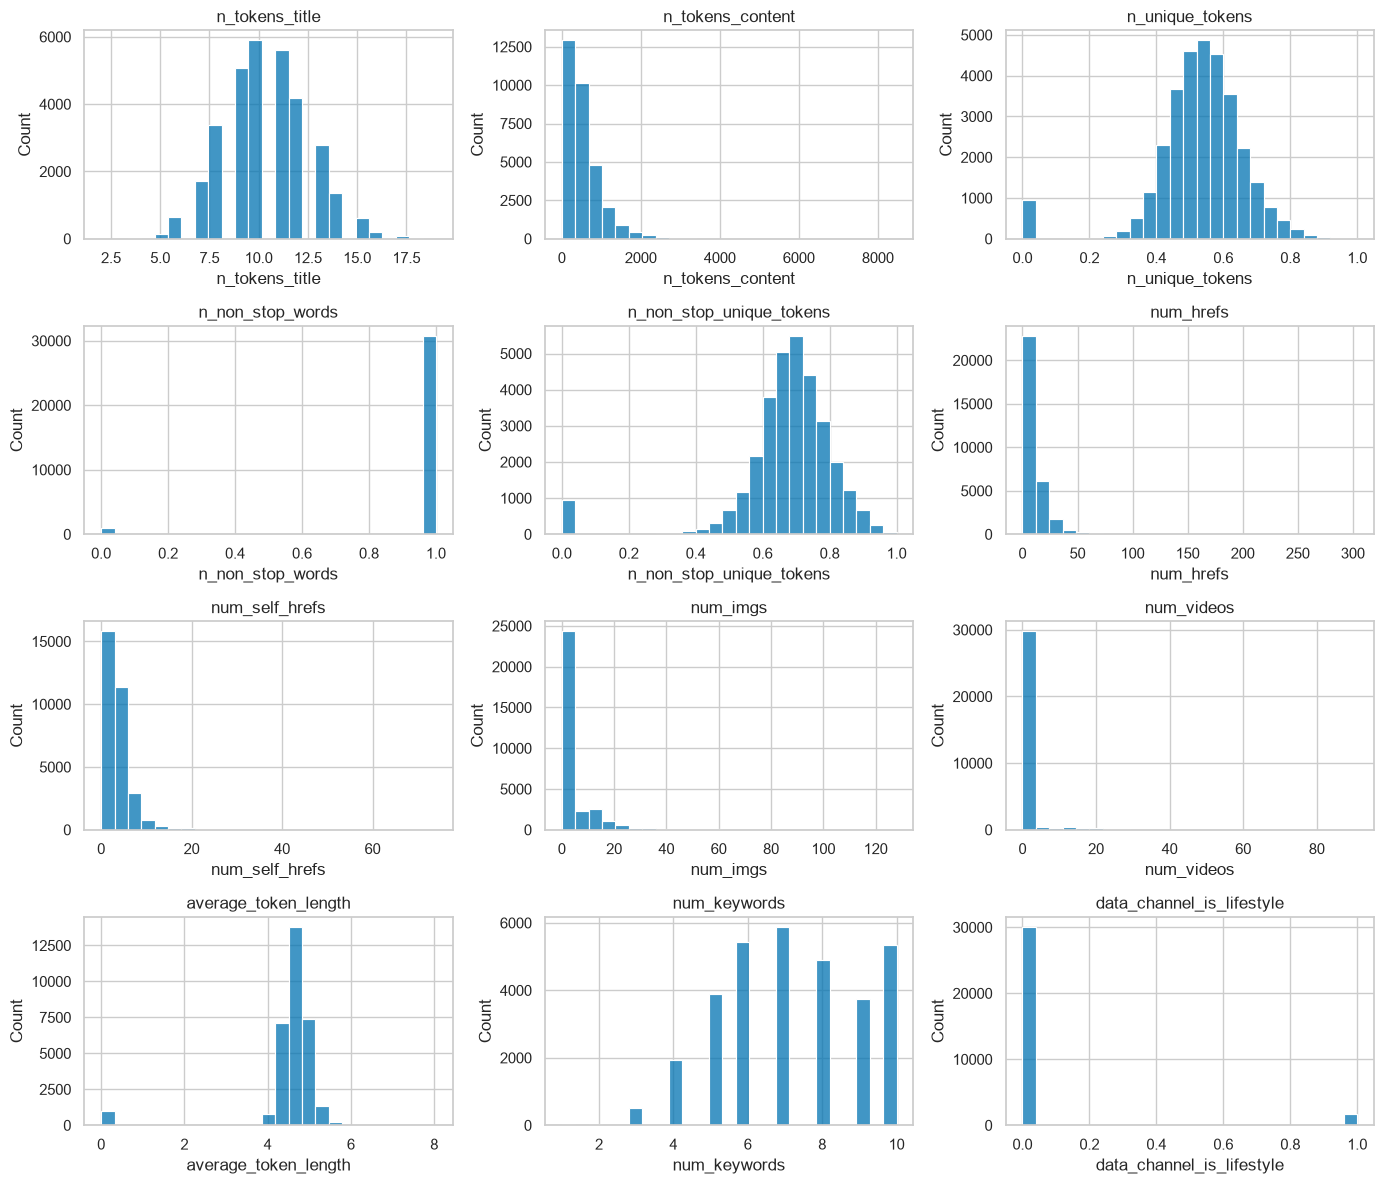

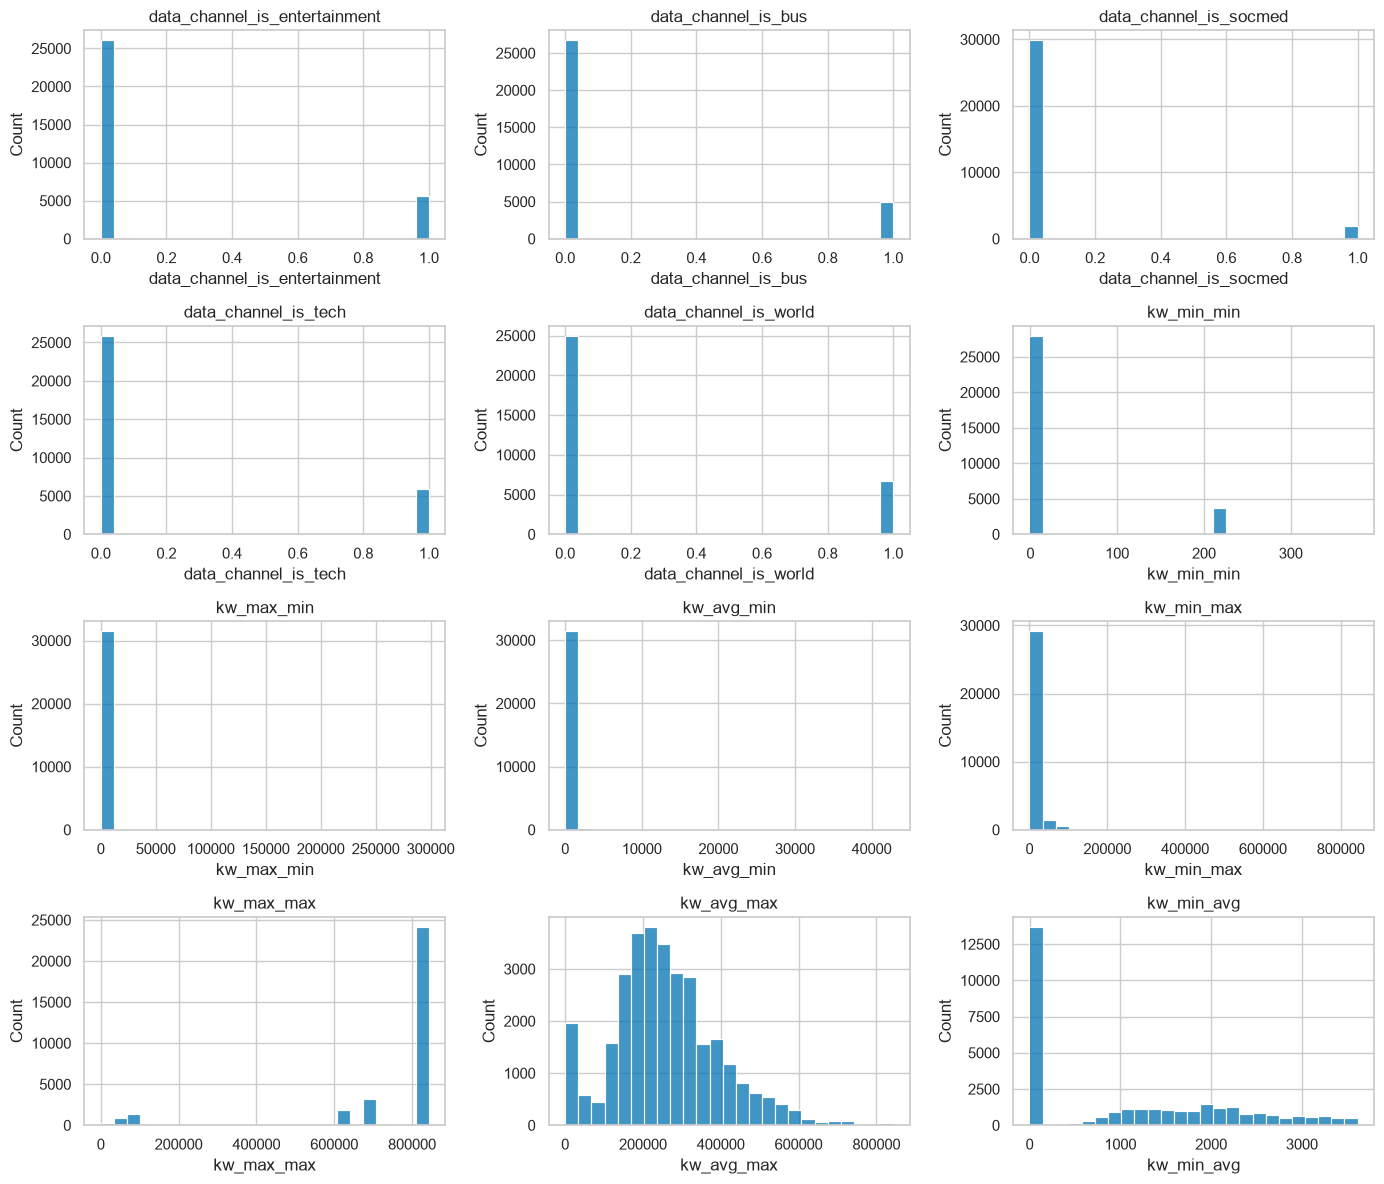

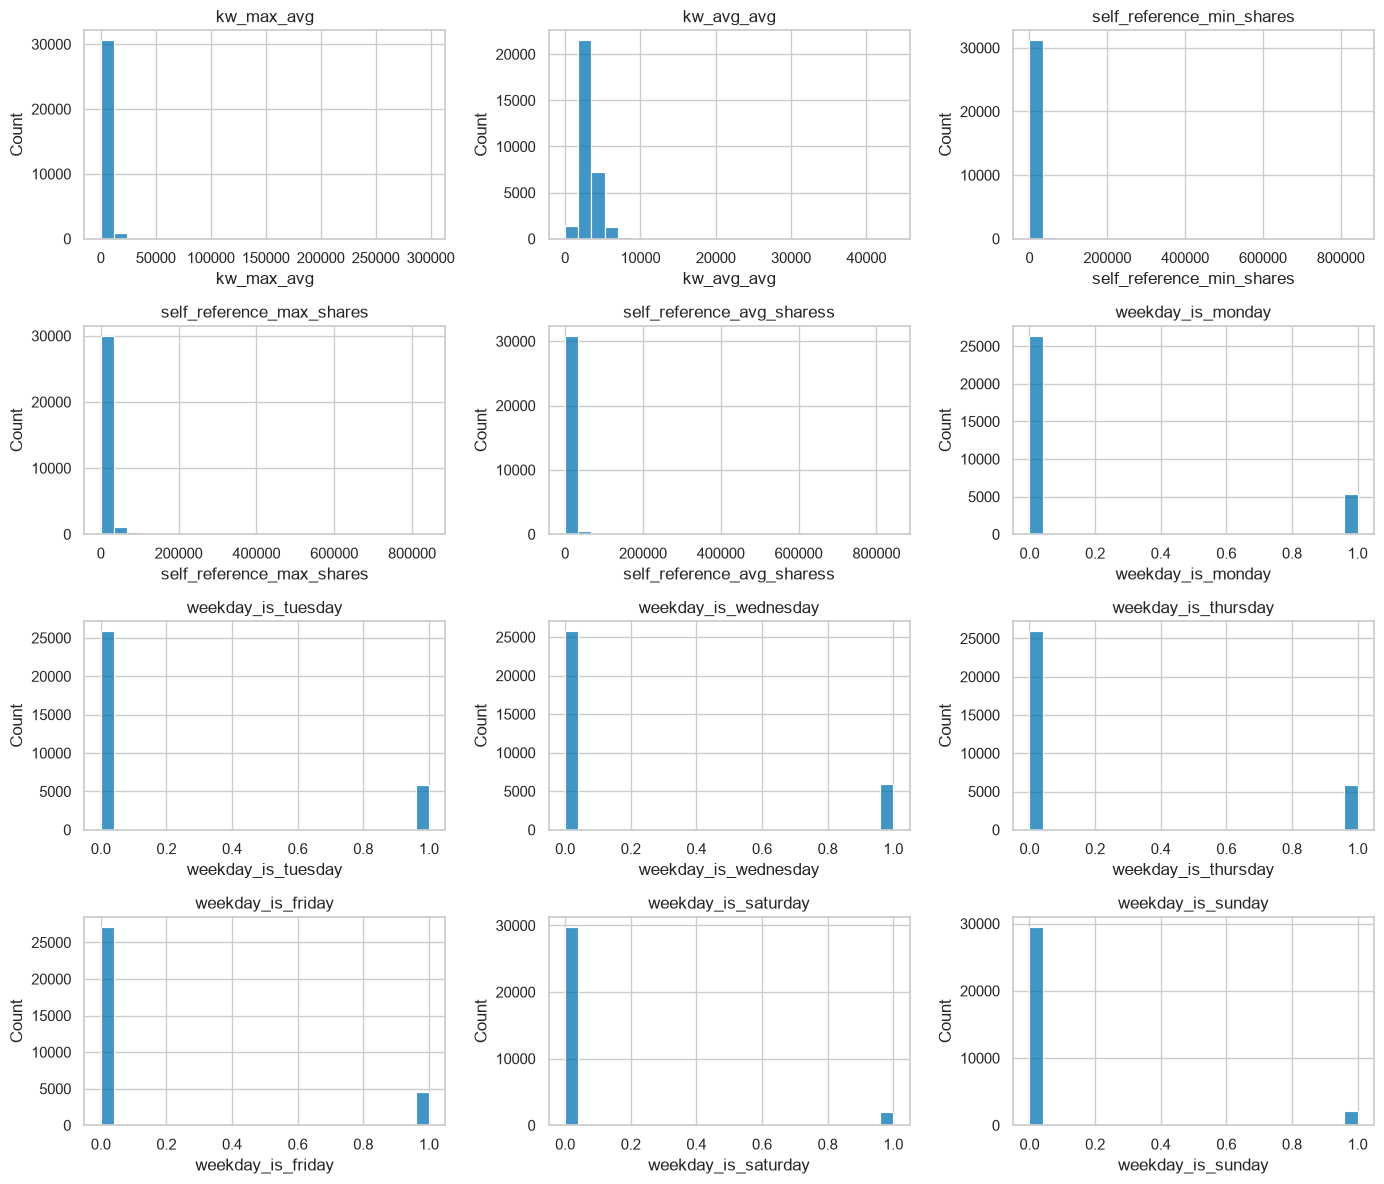

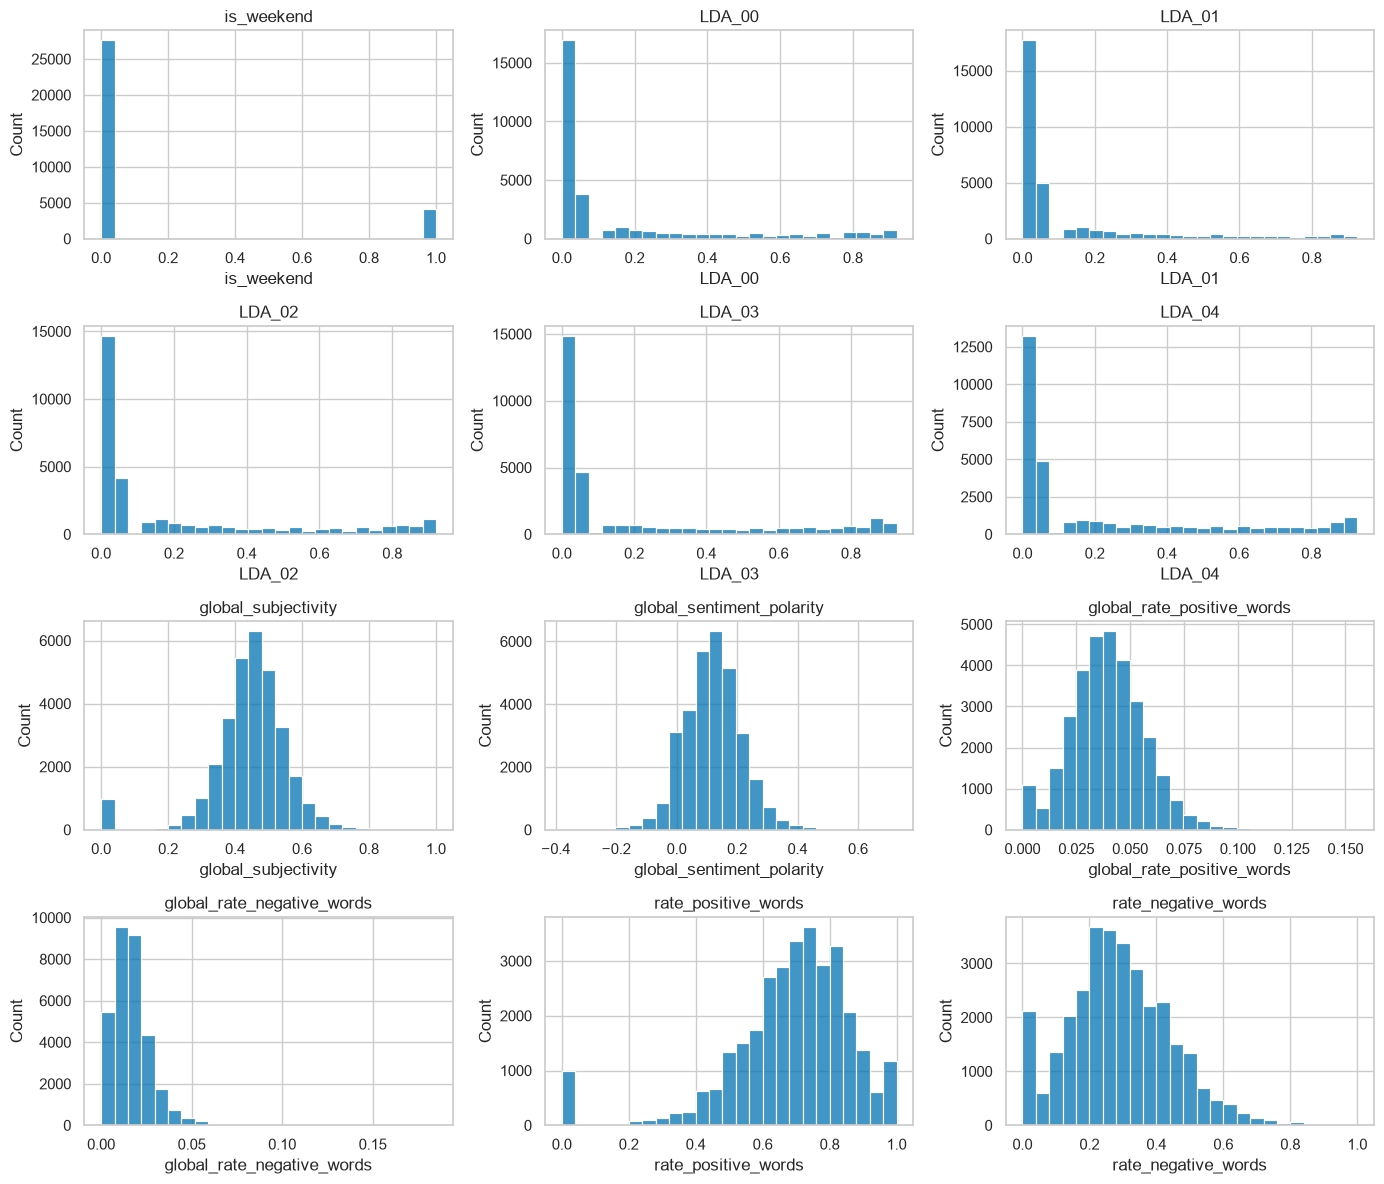

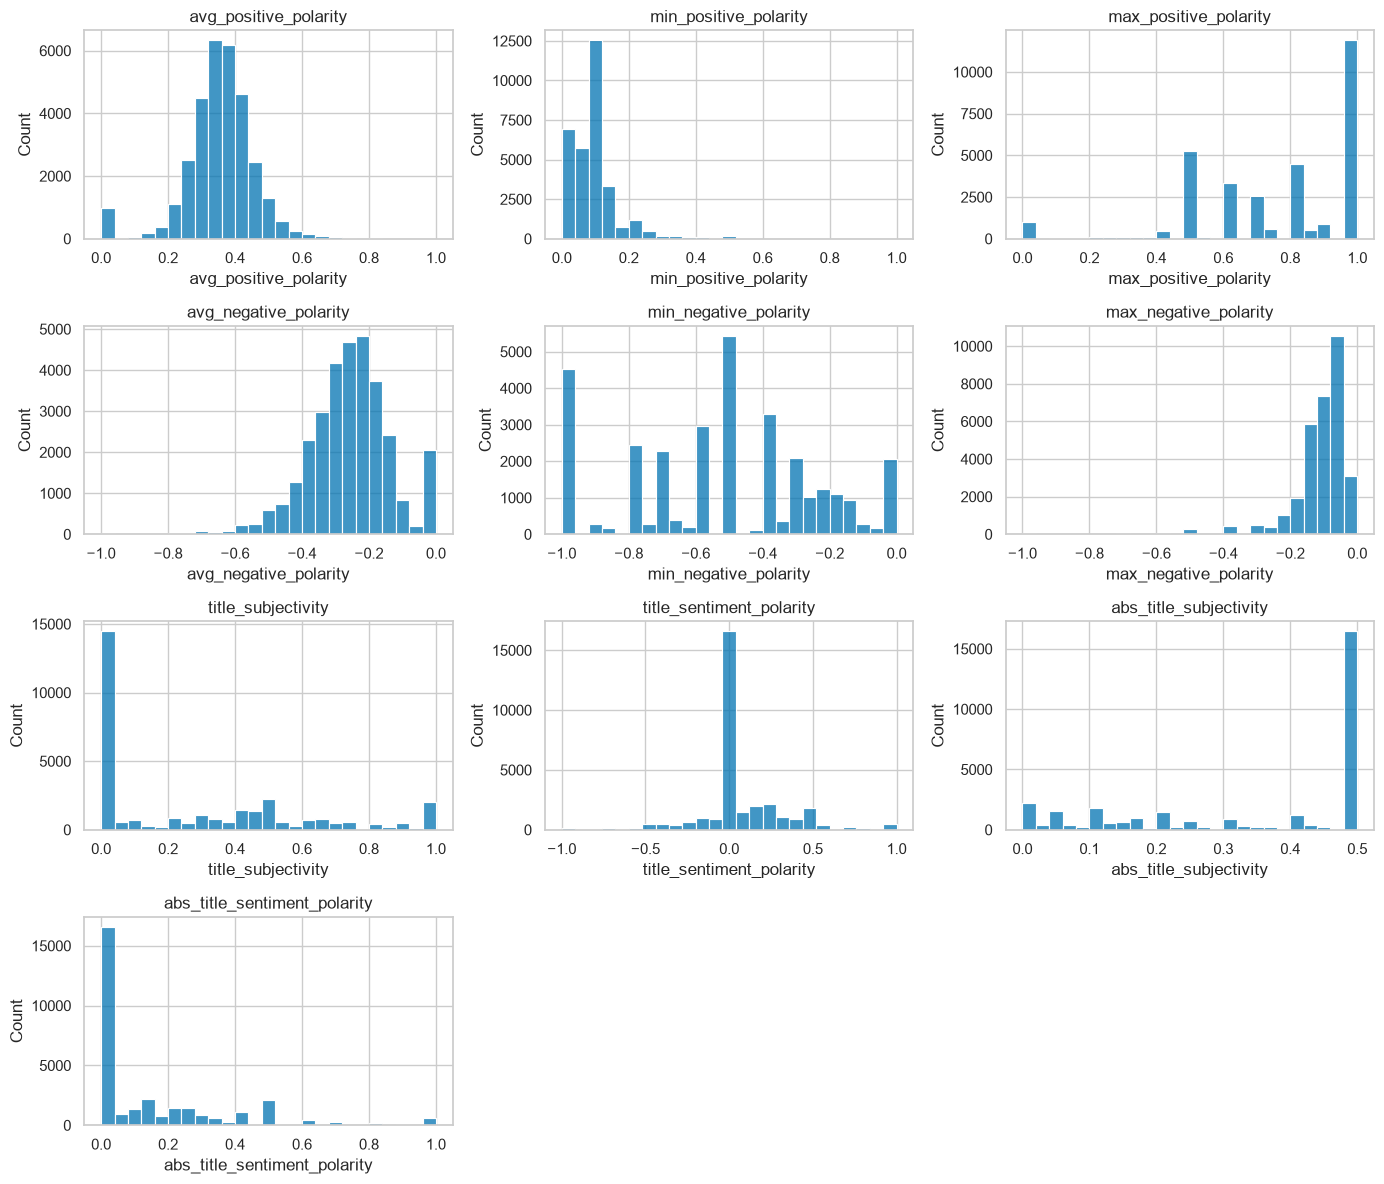

In [7]:
num = x_train.select_dtypes(include="number").columns.tolist()
for start in range(0, len(num), 12):
    cols = num[start:start + 12]
    fig, axes = plt.subplots(int(np.ceil(len(cols) / 3)), 3, figsize=(14, 3 * int(np.ceil(len(cols) / 3))))
    for ax, col in zip(axes.ravel(), cols):
        sns.histplot(x_train[col], bins=25, ax=ax)
        ax.set(title=col, xlabel=col, ylabel="Count")
    for ax in axes.ravel()[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

Article length, links, and keyword share counts have long right tails. The channel and weekday columns are binary. Word ratios, topic weights, and sentiment scores lie in much smaller ranges.

## Relationships and outliers

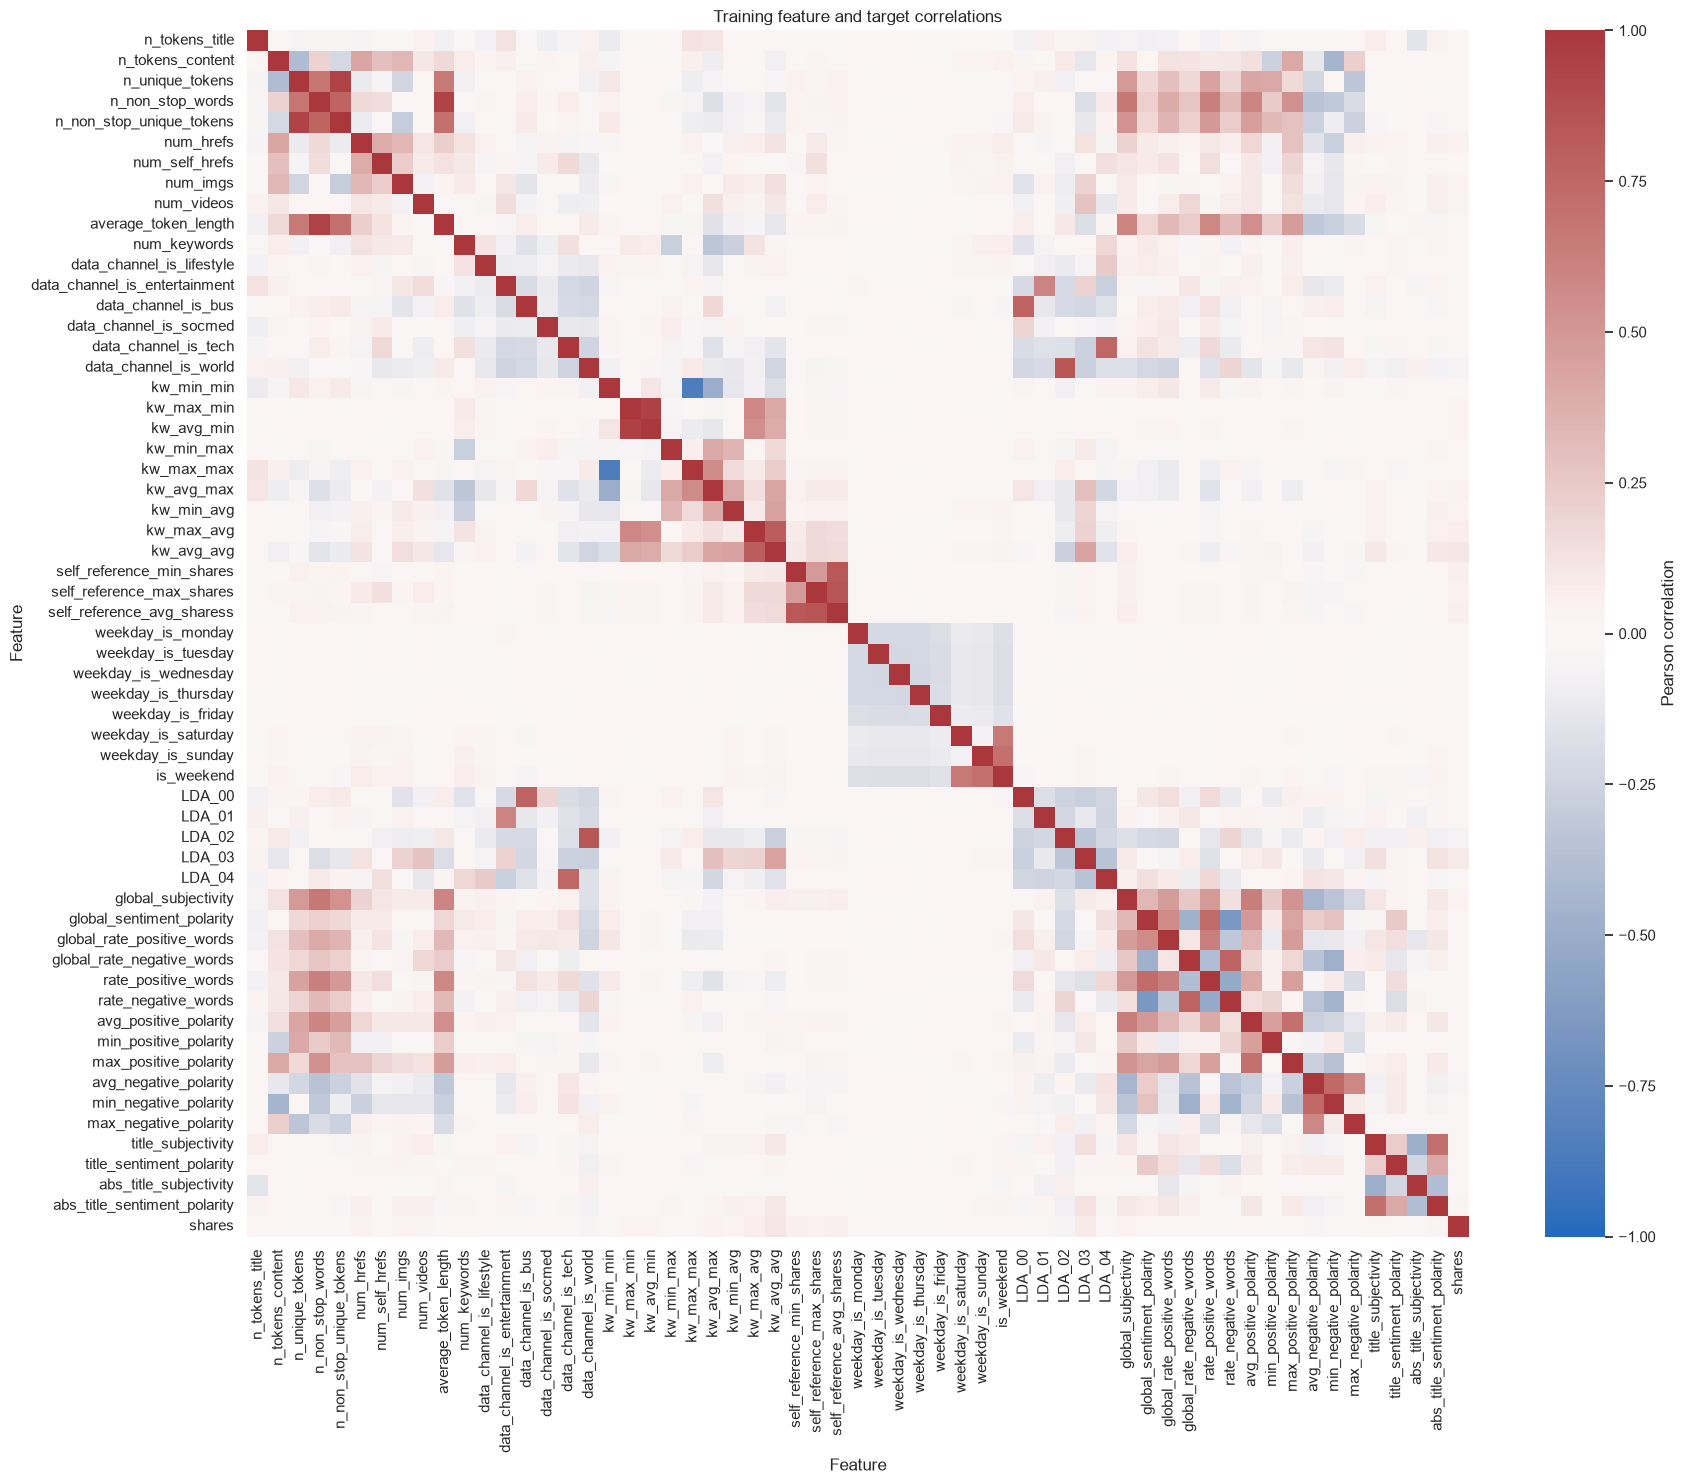

kw_avg_avg                    0.110656
LDA_03                        0.081403
kw_max_avg                    0.066058
self_reference_avg_sharess    0.060541
LDA_02                       -0.059763
self_reference_min_shares     0.057377
self_reference_max_shares     0.050508
kw_avg_max                    0.048818
Name: shares, dtype: float64

In [8]:
# full correlation heatmap plus top correlated features with shares
corr = data.select_dtypes(include="number").corr()
plt.figure(figsize=(18, 15))
sns.heatmap(corr, cmap="vlag", center=0, vmin=-1, vmax=1, cbar_kws={"label": "Pearson correlation"})
plt.title("Training feature and target correlations")
plt.xlabel("Feature")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
display(corr["shares"].drop("shares").sort_values(key=abs, ascending=False).head(8))

Keyword summaries are strongly correlated with each other. Several sentiment features also overlap. Individual correlations with shares are weak, suggesting that a simple linear relationship will explain only a small part of popularity.

The weak individual correlations with shares are a warning sign. If no single feature is strongly related to virality, it's going to be hard for any model to make accurate predictions. We might need combinations of features, which is why we'll try polynomial and tree-based models later.

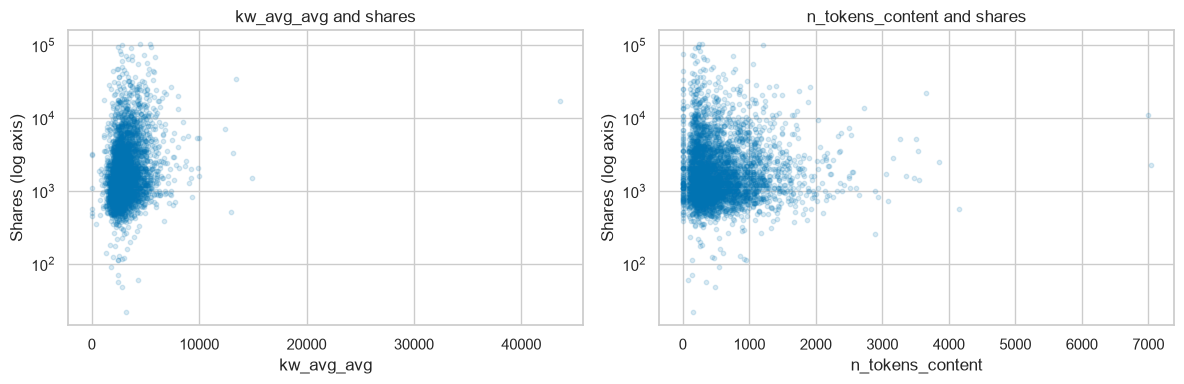

In [9]:
plot_df = data.sample(n=min(4000, len(data)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['kw_avg_avg', 'n_tokens_content']):
    values = plot_df["shares"].to_numpy(dtype=float)
    ax.set_yscale('log')
    ax.scatter(plot_df[col], values, alpha=0.15, s=10)
    ax.set(title=col + " and shares", xlabel=col, ylabel="Shares (log axis)")
plt.tight_layout()
plt.show()

Articles with similar lengths or keyword statistics can have very different share counts. Neither feature separates low-share and viral articles clearly.

In [10]:
# check for IQR-based outliers across all numeric features
q1 = x_train[num].quantile(0.25)
q3 = x_train[num].quantile(0.75)
iqr = q3 - q1
outside = (x_train[num] < q1 - 1.5 * iqr) | (x_train[num] > q3 + 1.5 * iqr)
display(outside.sum().sort_values(ascending=False).rename("IQR flags"))

kw_max_max                       7553
data_channel_is_world            6753
num_imgs                         6175
title_sentiment_polarity         6068
weekday_is_wednesday             5981
weekday_is_tuesday               5870
data_channel_is_tech             5853
weekday_is_thursday              5794
data_channel_is_entertainment    5660
weekday_is_monday                5349
data_channel_is_bus              5006
LDA_01                           4695
weekday_is_friday                4594
LDA_00                           4252
is_weekend                       4127
kw_min_max                       4056
self_reference_min_shares        3948
kw_min_min                       3763
self_reference_avg_sharess       3364
self_reference_max_shares        3332
kw_max_min                       2954
LDA_02                           2849
min_positive_polarity            2458
num_videos                       2369
n_non_stop_words                 2258
weekday_is_sunday                2195
max_negative

The IQR rule flags many large counts. Valid extremes are kept because popular articles are part of the prediction problem. Only the impossible word ratios were replaced. Log transforms reduce skew in the count features.

We're keeping the outliers because in this problem, the extreme values ARE part of what we're trying to predict. Removing viral articles would make the dataset easier to model, but then we'd be solving a different (and less useful) problem.

## Feature engineering

`media_per_100_words` measures how much visual content an article has relative to its length. Adding one to the denominator handles articles with zero recorded words. Representative features are kept from each group to keep polynomial regression manageable. Average keyword and reference share counts replace their min/max summaries. Weekend replaces the individual weekdays. One topic weight is dropped because the five topic weights sum to one.

In [11]:
# feature selection and engineering: pick representative features, add media density
cols = [
    'n_tokens_title', 'n_tokens_content', 'n_unique_tokens',
    'num_hrefs', 'num_self_hrefs', 'num_imgs',
    'num_videos', 'average_token_length', 'num_keywords',
    'kw_avg_avg', 'self_reference_avg_sharess', 'is_weekend',
    'data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus',
    'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world',
    'LDA_00', 'LDA_01', 'LDA_02',
    'LDA_03', 'global_subjectivity', 'global_sentiment_polarity',
    'rate_positive_words', 'avg_positive_polarity', 'avg_negative_polarity',
    'title_subjectivity', 'title_sentiment_polarity',
]
log_cols = ['n_tokens_content', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'kw_avg_avg', 'self_reference_avg_sharess']

In [12]:
# prepare() applies log transforms and creates new features
def prepare(x):
    x = x[cols].copy()
    x["media_per_100_words"] = 100 * (x["num_imgs"] + x["num_videos"]) / (x["n_tokens_content"] + 1)
    for col in log_cols:
        x[col] = np.log1p(x[col])
    return x

x_train = prepare(x_train)
x_test = prepare(x_test)
prep = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])

In [13]:
# fit scaler on training data only, then transform both sets
train_arr = prep.fit_transform(x_train)
test_arr = prep.transform(x_test)
names = prep.get_feature_names_out()
train = pd.DataFrame(train_arr, columns=names)
test = pd.DataFrame(test_arr, columns=names)
assert np.isfinite(train_arr).all() and np.isfinite(test_arr).all()
display(train.head())
print("Processed shapes:", train.shape, test.shape)

,n_tokens_title,n_tokens_content,n_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,kw_avg_avg,...,LDA_02,LDA_03,global_subjectivity,global_sentiment_polarity,rate_positive_words,avg_positive_polarity,avg_negative_polarity,title_subjectivity,title_sentiment_polarity,media_per_100_words
0,0.762488,-0.171430,0.509095,-0.673388,-0.744140,-0.437706,-0.589136,0.185413,-0.637172,-0.657038,...,-0.649009,-0.646098,0.126901,0.590804,0.731784,-0.543703,0.452983,-0.252206,0.264734,-0.089549
1,1.236595,0.518758,-0.400289,-0.093493,1.256750,-0.437706,0.427817,0.101966,0.934490,0.137604,...,0.393039,-0.683653,0.701916,0.371535,0.062732,0.142471,0.615303,-0.869120,-0.268469,-0.089881
2,1.236595,-0.081390,0.239140,-0.673388,0.578377,-0.437706,0.427817,-0.512310,1.458378,-0.121364,...,-0.696124,-0.691228,0.500250,1.305449,0.829199,0.625876,0.579834,0.783328,0.806898,-0.087942
3,0.762488,-4.669142,-3.855948,-2.659129,-1.744585,-1.149638,0.427817,-5.351659,0.410603,0.821640,...,-0.678494,0.655354,-3.780414,-1.229623,-3.576915,-3.377391,2.027233,0.729248,0.655369,0.503937
4,-1.608048,0.443425,-0.200725,0.682091,1.064019,0.849009,-0.589136,-0.224802,1.458378,0.000399,...,-0.696149,-0.009733,0.537107,-0.374725,-0.348993,-0.080037,-0.086946,2.215450,-0.268469,-0.085941


Processed shapes: (31715, 30) (7929, 30)


Median imputation and StandardScaler are fitted on the training set. News categories are already stored as binary columns, so they do not need one-hot encoding.

Since all features are numeric (the channel and weekday columns are already binary 0/1), we don't need one-hot encoding. The pipeline is just imputation plus scaling. Simple and clean.

## Saving the datasets

The processed CSVs contain model-ready values. The `_raw` files preserve the same split before imputation and scaling so cross-validation can fit these steps within each fold.

In [14]:
# save processed CSVs for the regression notebook
train["shares"] = y_train.to_numpy()
test["shares"] = y_test.to_numpy()
train.to_csv("../processed_datasets/news_train.csv", index=False)
test.to_csv("../processed_datasets/news_test.csv", index=False)

In [15]:
raw_train = x_train.copy()
raw_test = x_test.copy()
raw_train["shares"] = y_train
raw_test["shares"] = y_test
raw_train.to_csv("../processed_datasets/news_train_raw.csv", index=False)
raw_test.to_csv("../processed_datasets/news_test_raw.csv", index=False)

In [16]:
split = pd.DataFrame({"source_row": list(x_train.index) + list(x_test.index),
                      "split": ["train"] * len(x_train) + ["test"] * len(x_test)})
split.to_csv("../processed_datasets/news_split_rows.csv", index=False)
assert set(x_train.index).isdisjoint(x_test.index)
print("Saved processed data, unscaled companion data, and original row assignments.")

Saved processed data, unscaled companion data, and original row assignments.
